# Adding a cluster feature to the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [26]:
script = Path.cwd()
root = script.parent
df=  pd.read_csv(root/"data"/"cleaned_data"/'cleaned_data.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           36992 non-null  float64
 1   gender                        36992 non-null  str    
 2   security_no                   36992 non-null  str    
 3   region_category               36992 non-null  str    
 4   membership_category           36992 non-null  str    
 5   joining_date                  36992 non-null  str    
 6   joined_through_referral       36992 non-null  str    
 7   referral_id                   36992 non-null  str    
 8   preferred_offer_types         36992 non-null  str    
 9   medium_of_operation           36992 non-null  str    
 10  internet_option               36992 non-null  str    
 11  last_visit_time               36992 non-null  str    
 12  days_since_last_login         36992 non-null  float64
 13  avg_time_spe

In [5]:
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'],errors = 'coerce')

In [6]:
features = ['age',
    'avg_time_spent',
    'avg_transaction_value',
    'avg_frequency_login_days',
    'points_in_wallet',
    'days_since_last_login'
]

In [7]:
x_cluster = df[features].copy()

In [8]:
for col in features:
    x_cluster[col] = pd.to_numeric(x_cluster[col],errors = 'coerce')
    x_cluster[col] = x_cluster[col].fillna(x_cluster[col].median())

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

In [11]:
x_scaled = scaler.fit_transform(x_cluster)

In [12]:
from sklearn.cluster import KMeans

In [13]:
inertia = []

# How many groups should I Split customers?

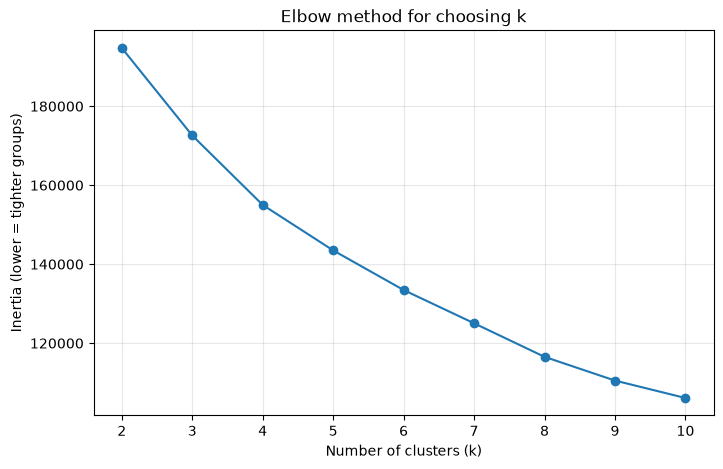

In [14]:
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (lower = tighter groups)')
plt.title('Elbow method for choosing k')
plt.grid(True, alpha=0.3)
plt.show()

### so we can take K=4 

In [15]:
k=4
k_means = KMeans(n_clusters = k,random_state = 42,n_init=10)
df['cluster'] = k_means.fit_predict(x_scaled)

In [16]:
df['cluster']

0        3
1        1
2        0
3        1
4        1
        ..
36987    1
36988    1
36989    1
36990    0
36991    1
Name: cluster, Length: 36992, dtype: int32

In [17]:
df['cluster'].value_counts()

cluster
1    15315
0    12390
3     5526
2     3761
Name: count, dtype: int64

In [18]:
print(df['cluster'].value_counts(normalize=True) * 100) 

cluster
1    41.400843
0    33.493728
3    14.938365
2    10.167063
Name: proportion, dtype: float64


In [19]:
cluster_profile  = df.groupby('cluster')[features].mean()

In [20]:
print(cluster_profile)

               age  avg_time_spent  avg_transaction_value  \
cluster                                                     
0        52.047861      195.115120           23516.369443   
1        25.054652      166.044538           24220.486335   
2        36.734645     1071.942562           27952.924690   
3        37.369888      241.440109           56592.092025   

         avg_frequency_login_days  points_in_wallet  days_since_last_login  
cluster                                                                     
0                       17.518079        664.501779              13.148023  
1                       17.742973        669.660799              13.176363  
2                       16.602418        677.214523              11.183728  
3                        7.984208        802.210907              12.002172  


In [21]:
churn_by_cluster = df.groupby('cluster')['churn_risk_score'].mean().sort_values()
print(churn_by_cluster)

cluster
3    0.240680
2    0.570327
0    0.599919
1    0.643813
Name: churn_risk_score, dtype: float64


So cluster 3 shows the lowest churn!

In [22]:
df.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,cluster
0,18.0,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,no referral id,Gift Vouchers/Coupons,Not Provided,...,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0.0,3
1,32.0,F,5K0N3X1,City,Premium Membership,2017-08-28,No Information available,CID21329,Gift Vouchers/Coupons,Desktop,...,12838.38,10.0,698.03,Yes,No,Yes,Solved,Quality Customer Care,0.0,1
2,44.0,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,Desktop,...,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1.0,0
3,37.0,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,Desktop,...,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1.0,1
4,31.0,F,SVZXCWB,City,No Membership,2017-09-12,No,no referral id,Credit/Debit Card Offers,Smartphone,...,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1.0,1


In [25]:
df.to_csv(root/"data"/"cleaned_data"/'clean_clustered.csv')
print(f"Saved clean_clustered.csv successfully to {root/"data"/"cleaned_data"/'clean_clustered.csv'} ✅")

Saved clean_clustered.csv successfully to d:\Customer Segmntation and retention analysis\data\cleaned_data\clean_clustered.csv ✅
